
## K-Means Customer Segmentation Analysis


In [5]:
import pandas as pd
import numpy as np


from sklearn.cluster import KMeans


import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [35]:
from sklearn.datasets import make_blobs, load_iris

In [6]:
#1.อ่านไฟล์
Mall = pd.read_csv('Mall_Customers.csv')
print(Mall)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [7]:
#2.แสดงผล 10 บรรทัดแรก
Mall.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [8]:
#3.หาค่าสถิติพื้นฐาน
Mall.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


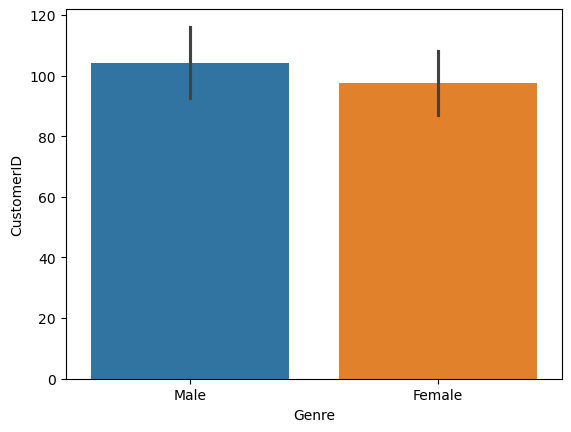

In [18]:
#4.ดูการแจกแจง โดยแสดงกราฟแท่งของลูกค้าแยกตามเพศ มีตัวอย่างคำสั่งในการ plot หลายรูปแบบ
sns.barplot(x='Genre',y ='CustomerID', hue='Genre', data=Mall)
plt.show()

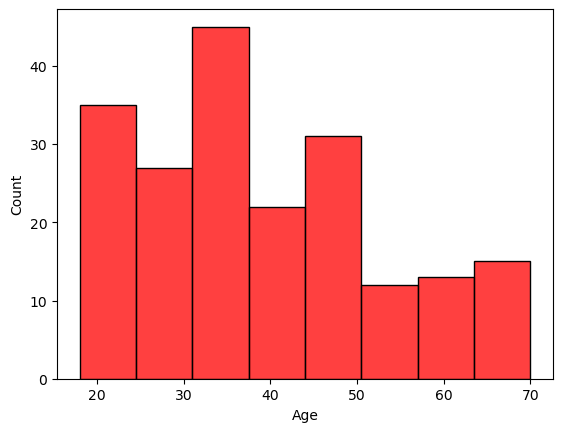

In [24]:
#5.สร้าง histogram,pie ของอายุ แบ่งเป็น 8 bin
sns.histplot(data=Mall, x="Age",bins = 8 ,color = 'red')
plt.show()

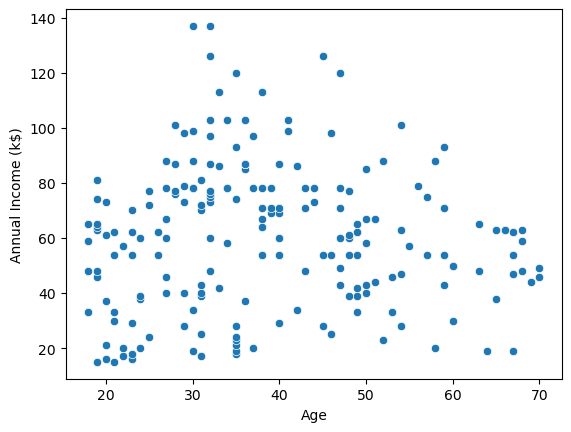

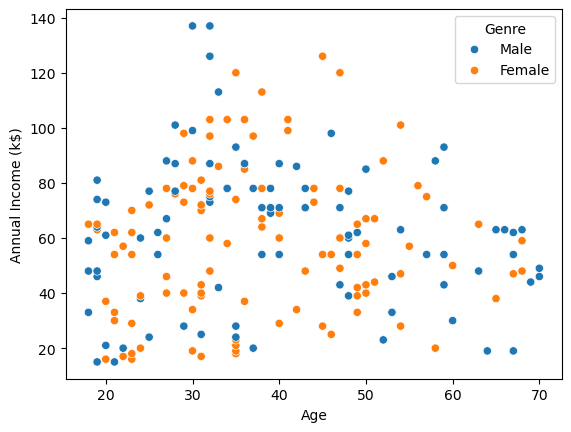

In [29]:
#6.ทำ scatter plot,pie ของข้อมูล Age, Income ทั้งแบบแยกและไม่แยกตามเพศ
sns.scatterplot(x='Age',y='Annual Income (k$)',data=Mall,)
plt.show()

sns.scatterplot(x='Age',y='Annual Income (k$)',data=Mall,hue='Genre')
plt.show()

1 176108.78
2 87159.30436535942
3 59525.85757379875
4 39502.77850064538
5 33038.288997113996
6 29000.58013211382
7 23727.99481482667
8 18888.22504796246
9 17015.13709661931


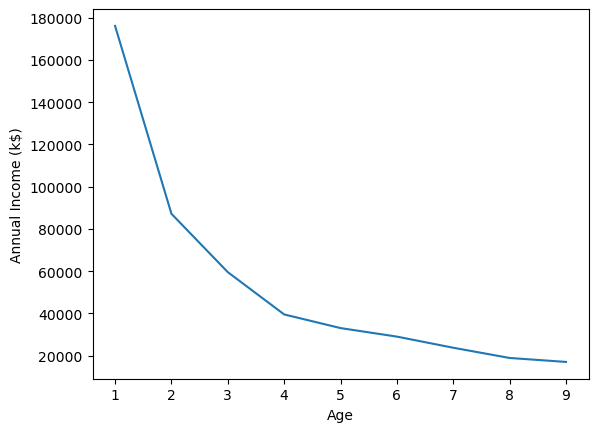

In [52]:
#7.นำ ข้อมูล Age, Income มาทำ clustering พิจารณาค่า K ที่ดีที่สุดเพื่อนำไปทำ K-Mean clustering
X1 = Mall [['Age','Annual Income (k$)']]

sse = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=500)
    kmeans.fit(X1)
    sse[k] = kmeans.inertia_
    print(k,sse[k])
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.show()

In [48]:
#8.ได้ค่า k= ? ในการจัดกลุ่มโดยวิธี K-Means
K = 4

In [109]:
#9. แสดงเลขกลุ่มที่ข้อมูลแต่ละตัวอยู่กลุ่มไหน 
k_means = KMeans(n_clusters=4,max_iter=500).fit(X1)
Mall_cluster = kmeans.fit_predict(X1)
Mall_cluster_label = k_means.labels_
print(Mall_cluster_label)

[1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1
 1 1 1 0 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0
 0 2 0 0 2 0 0 0 0 0 2 0 0 2 2 0 0 2 0 2 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 2 2 2 2 0 0 0 0 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 3 2 3 2 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


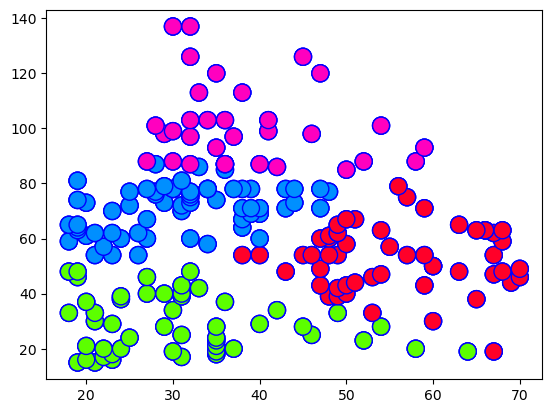

In [131]:
#10.ทำ scatter plot ที่แสดง centroid
plt.scatter(X1['Age'], X1['Annual Income (k$)'], c=Mall_cluster_label, cmap='gist_rainbow', edgecolor='b', s=150)
plt.show()